Phân tích dữ liệu chuỗi thời gian với mô hình ARIMA, SARIMA, Holt-Winters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


def adf_test(x):
    indices = ['ADF Statistic', 'p-value', 'Lags Used', 'Observations']
    test = adfuller(x, autolag='AIC')
    results = pd.Series(test[:4], index=indices)
    for key, val in test[4].items():
        results[f'Critical Value ({key})'] = val
    verdict = 'Reject H0 → STATIONARY ✅' if results['p-value'] <= 0.05 else 'Fail to reject H0 → NON-STATIONARY ❌'
    print(verdict)
    return results


def kpss_test(x):
    indices = ['KPSS Statistic', 'p-value', 'Lags Used']
    test = kpss(x)
    results = pd.Series(test[:3], index=indices)
    for key, val in test[3].items():
        results[f'Critical Value ({key})'] = val
    verdict = 'Reject H0 → NON-STATIONARY ❌' if results['p-value'] <= 0.05 else 'Fail to reject H0 → STATIONARY ✅'
    print(verdict)
    return results


## 1. Load và Khám phá Dữ liệu

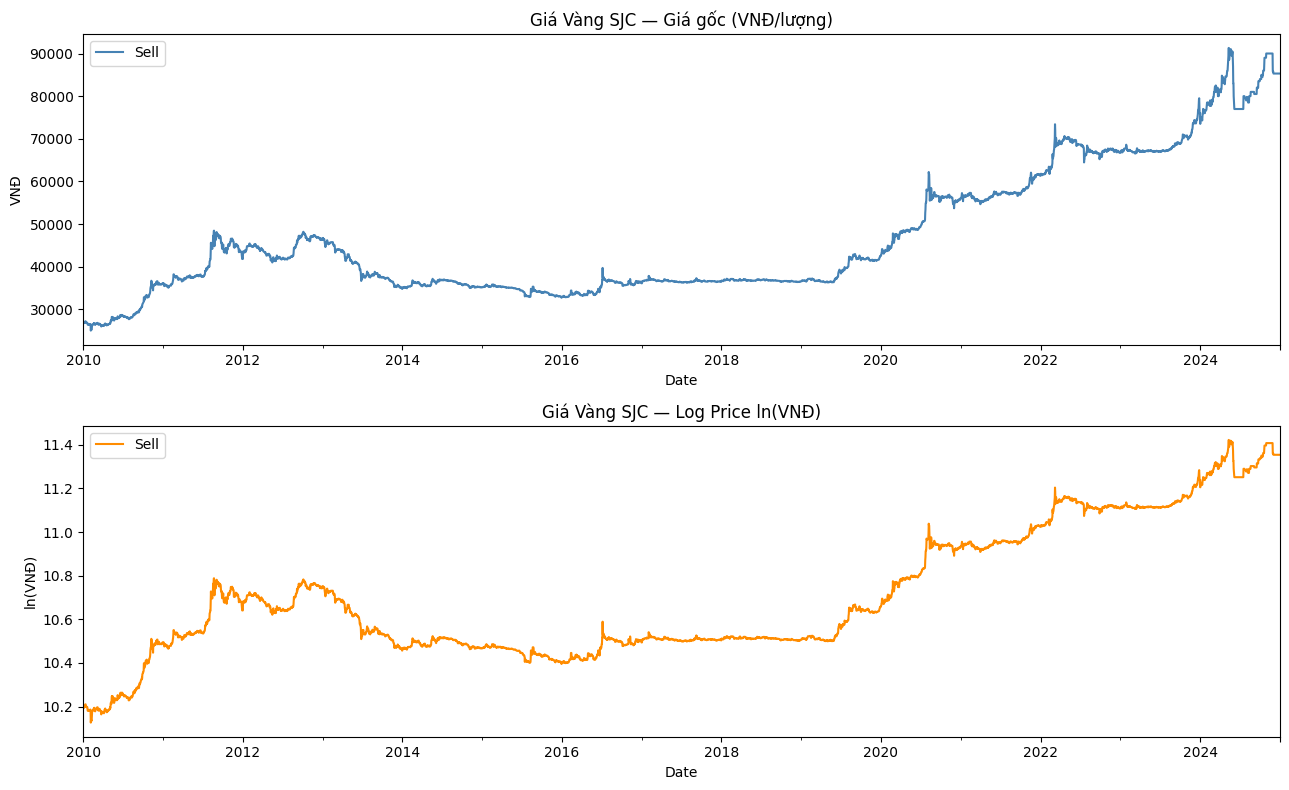

In [2]:
df = pd.read_excel('data/GoldSJC_2010_2025.xlsx', index_col='Date', parse_dates=True)
df = df[['Sell']].resample('D').ffill()  # Điền khoảng trống ngày nghỉ/lễ bằng forward-fill

df_log = np.log(df)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
df.plot(ax=axes[0], title='Giá Vàng SJC — Giá gốc (VNĐ/lượng)', color='steelblue')
axes[0].set_ylabel('VNĐ')
df_log.plot(ax=axes[1], title='Giá Vàng SJC — Log Price ln(VNĐ)', color='darkorange')
axes[1].set_ylabel('ln(VNĐ)')
plt.tight_layout()
plt.show()


In [3]:
print('=== Thông tin Dataset ===')
df.info()
print('\n=== Thống kê mô tả (giá gốc VNĐ) ===')
print(df.describe())
print(f'\nNgày đầu  : {df.index[0].date()}')
print(f'Ngày cuối : {df.index[-1].date()}')
print(f'Tổng quan sát: {len(df)} ngày (calendar daily, ffill weekends/holidays)')


=== Thông tin Dataset ===
<class 'pandas.DataFrame'>
DatetimeIndex: 5480 entries, 2010-01-01 to 2025-01-01
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sell    5480 non-null   int64
dtypes: int64(1)
memory usage: 85.6 KB

=== Thống kê mô tả (giá gốc VNĐ) ===
               Sell
count   5480.000000
mean   46605.620438
std    15180.874005
min    25000.000000
25%    36350.000000
50%    38500.000000
75%    56700.000000
max    91300.000000

Ngày đầu  : 2010-01-01
Ngày cuối : 2025-01-01
Tổng quan sát: 5480 ngày (calendar daily, ffill weekends/holidays)


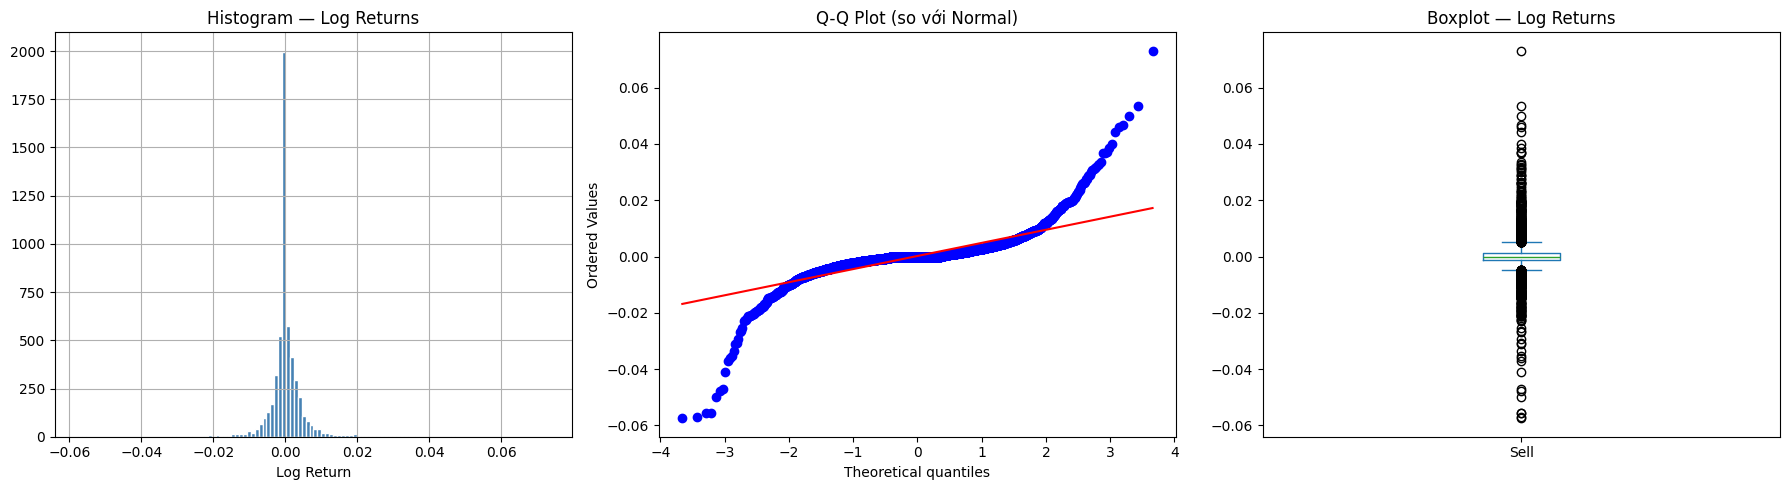

Skewness        : 0.3231
Excess Kurtosis : 29.0379  →  Heavy tails / Leptokurtic ⚠️
D'Agostino-Pearson: p = 0.000000  →  KHÔNG phân phối chuẩn ⚠️


In [4]:
# Phase 1b: Phân tích phân phối Log Returns & Heavy Tails
log_returns = df_log['Sell'].diff().dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_returns.hist(bins=120, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histogram — Log Returns')
axes[0].set_xlabel('Log Return')

stats.probplot(log_returns, plot=axes[1])
axes[1].set_title('Q-Q Plot (so với Normal)')

log_returns.plot(kind='box', ax=axes[2])
axes[2].set_title('Boxplot — Log Returns')

plt.tight_layout()
plt.show()

skew  = log_returns.skew()
kurt  = log_returns.kurtosis()  # excess kurtosis (normal = 0)
_, p_norm = stats.normaltest(log_returns)
print(f'Skewness        : {skew:.4f}')
print(f'Excess Kurtosis : {kurt:.4f}  →  {"Heavy tails / Leptokurtic ⚠️" if abs(kurt) > 1 else "Near-normal tails"}')
print(f"D'Agostino-Pearson: p = {p_norm:.6f}  →  {'KHÔNG phân phối chuẩn ⚠️' if p_norm < 0.05 else 'Phân phối chuẩn ✅'}")


## a) Phân rã dữ liệu (Decomposition) và Nhận xét

<Axes: title={'center': 'Residual'}, xlabel='Date'>

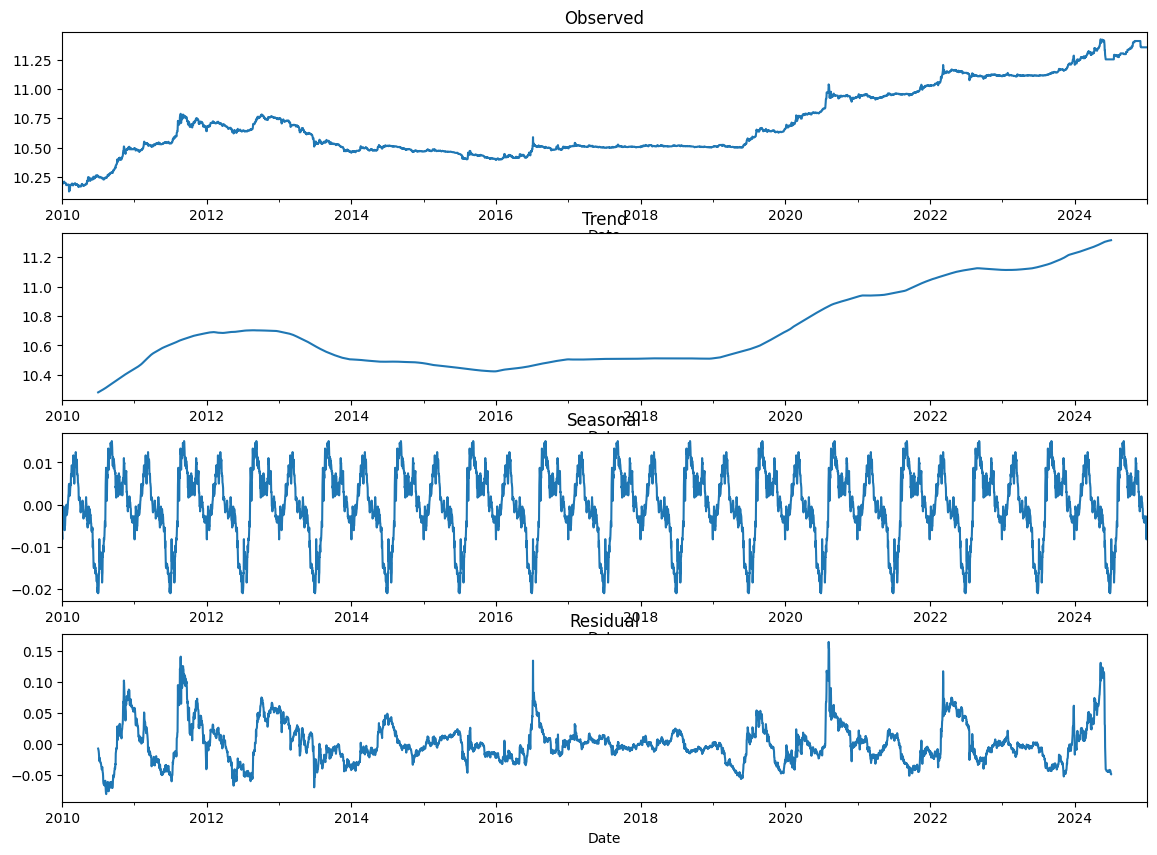

In [16]:
# period=252 cho trading days/năm, hoặc 12 cho monthly
result = seasonal_decompose(df_log, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1],    title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3],   title='Residual')


## b) Kiểm định tính dừng và Tương quan

Fail to reject H0 → NON-STATIONARY ❌
ADF Test: ADF Statistic             -0.177076
p-value                    0.941200
Lags Used                 12.000000
Observations            5467.000000
Critical Value (1%)       -3.431547
Critical Value (5%)       -2.862069
Critical Value (10%)      -2.567051
dtype: float64
Reject H0 → NON-STATIONARY ❌

KPSS Test: KPSS Statistic            8.302877
p-value                   0.010000
Lags Used                44.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


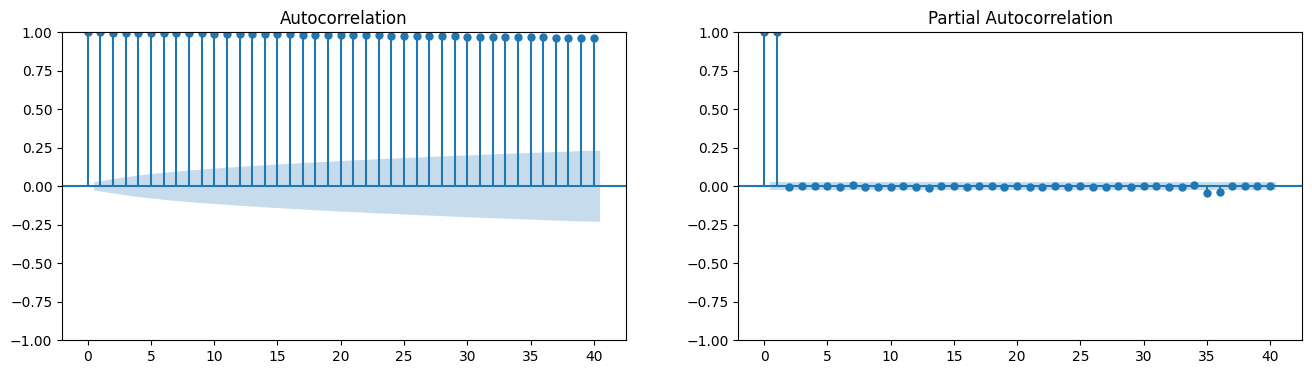

In [6]:
print("ADF Test:", adf_test(df_log))
print("\nKPSS Test:", kpss_test(df_log))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log, ax=ax1, lags=40)
plot_pacf(df_log, ax=ax2, lags=40)
plt.show()

=== Sau khi lấy sai phân bậc 1 (Log Returns) ===
ADF Test:
Reject H0 → STATIONARY ✅
ADF Statistic            -19.178828
p-value                    0.000000
Lags Used                 11.000000
Observations            5467.000000
Critical Value (1%)       -3.431547
Critical Value (5%)       -2.862069
Critical Value (10%)      -2.567051
dtype: float64

KPSS Test:
Fail to reject H0 → STATIONARY ✅
KPSS Statistic           0.275048
p-value                  0.100000
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


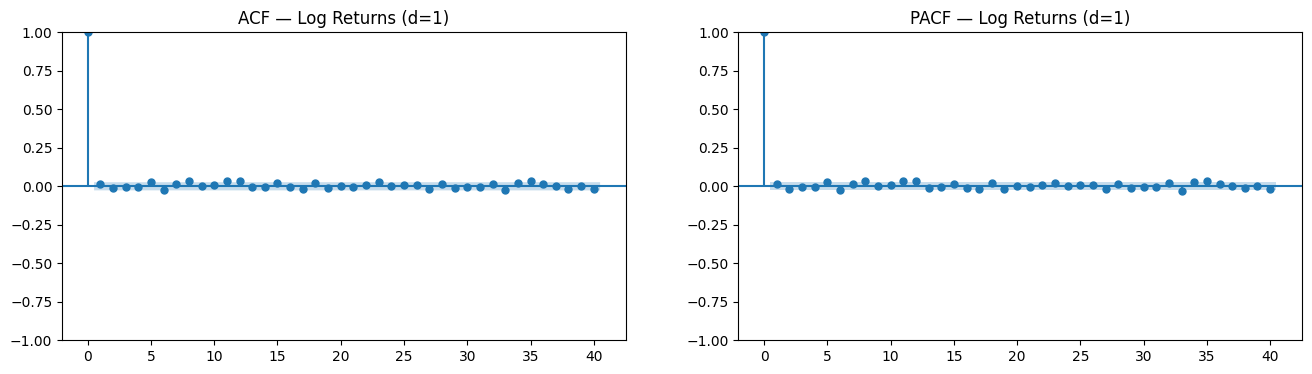

In [7]:
# Sai phân bậc 1 của Log Price = Log Returns: ln(Pt) - ln(Pt-1)
df_log_diff = df_log.diff().dropna()

print('=== Sau khi lấy sai phân bậc 1 (Log Returns) ===')
print('ADF Test:')
print(adf_test(df_log_diff))
print('\nKPSS Test:')
print(kpss_test(df_log_diff))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_diff,  ax=ax1, lags=40, title='ACF — Log Returns (d=1)')
plot_pacf(df_log_diff, ax=ax2, lags=40, title='PACF — Log Returns (d=1)')
plt.show()


# Ý Nghĩa Các Tham Số Trong Mô Mô Hình ARIMA $(p, d, q)$

Mô hình ARIMA được cấu thành từ ba tham số cơ bản: **p** (Auto Regressive), **d** (Integrated), và **q** (Moving Average). Dưới đây là ý nghĩa chi tiết của từng tham số:

---

### 🔹 Tham số $p$ (Bậc của thành phần Tự hồi quy - AR)
* **Định nghĩa:** $p$ là bậc của thuật ngữ Tự hồi quy (Auto Regressive). Nó đại diện cho số lượng khoảng trễ (lags) của biến mục tiêu $Y$ được sử dụng làm biến dự báo trong mô hình.
* **Bản chất:** Thuật ngữ "Tự hồi quy" trong ARIMA ám chỉ đây là một mô hình hồi quy tuyến tính sử dụng chính các giá trị trong quá khứ của nó để dự báo cho tương lai.

---

### 🔹 Tham số $d$ (Số lần lấy sai phân - I)
* **Bản chất của dữ liệu:** Các mô hình hồi quy tuyến tính hoạt động tốt nhất khi các biến dự báo không có sự tương quan và độc lập với nhau. Do đó, chúng ta cần phải biến đổi chuỗi thời gian về trạng thái **dừng (stationary)**.
* **Cách thực hiện:** Phương pháp phổ biến nhất để biến chuỗi thời gian thành chuỗi dừng là lấy sai phân (differencing) — tức là lấy giá trị hiện tại trừ đi giá trị ngay trước nó. Tùy thuộc vào độ phức tạp của chuỗi dữ liệu, bạn có thể cần phải lấy sai phân nhiều hơn một lần.
* **Định nghĩa:** Giá trị của $d$ là số lần lấy sai phân tối thiểu cần thiết để biến chuỗi thời gian thành chuỗi dừng. 
  * Nếu chuỗi thời gian vốn đã định sẵn là chuỗi dừng, thì $d = 0$.

---

### 🔹 Tham số $q$ (Bậc của thành phần Trung bình trượt - MA)
* **Định nghĩa:** $q$ là bậc của thuật ngữ Trung bình trượt (Moving Average). Nó đại diện cho số lượng sai số dự báo trong quá khứ (lagged forecast errors) được đưa vào mô hình ARIMA để điều chỉnh dự báo.


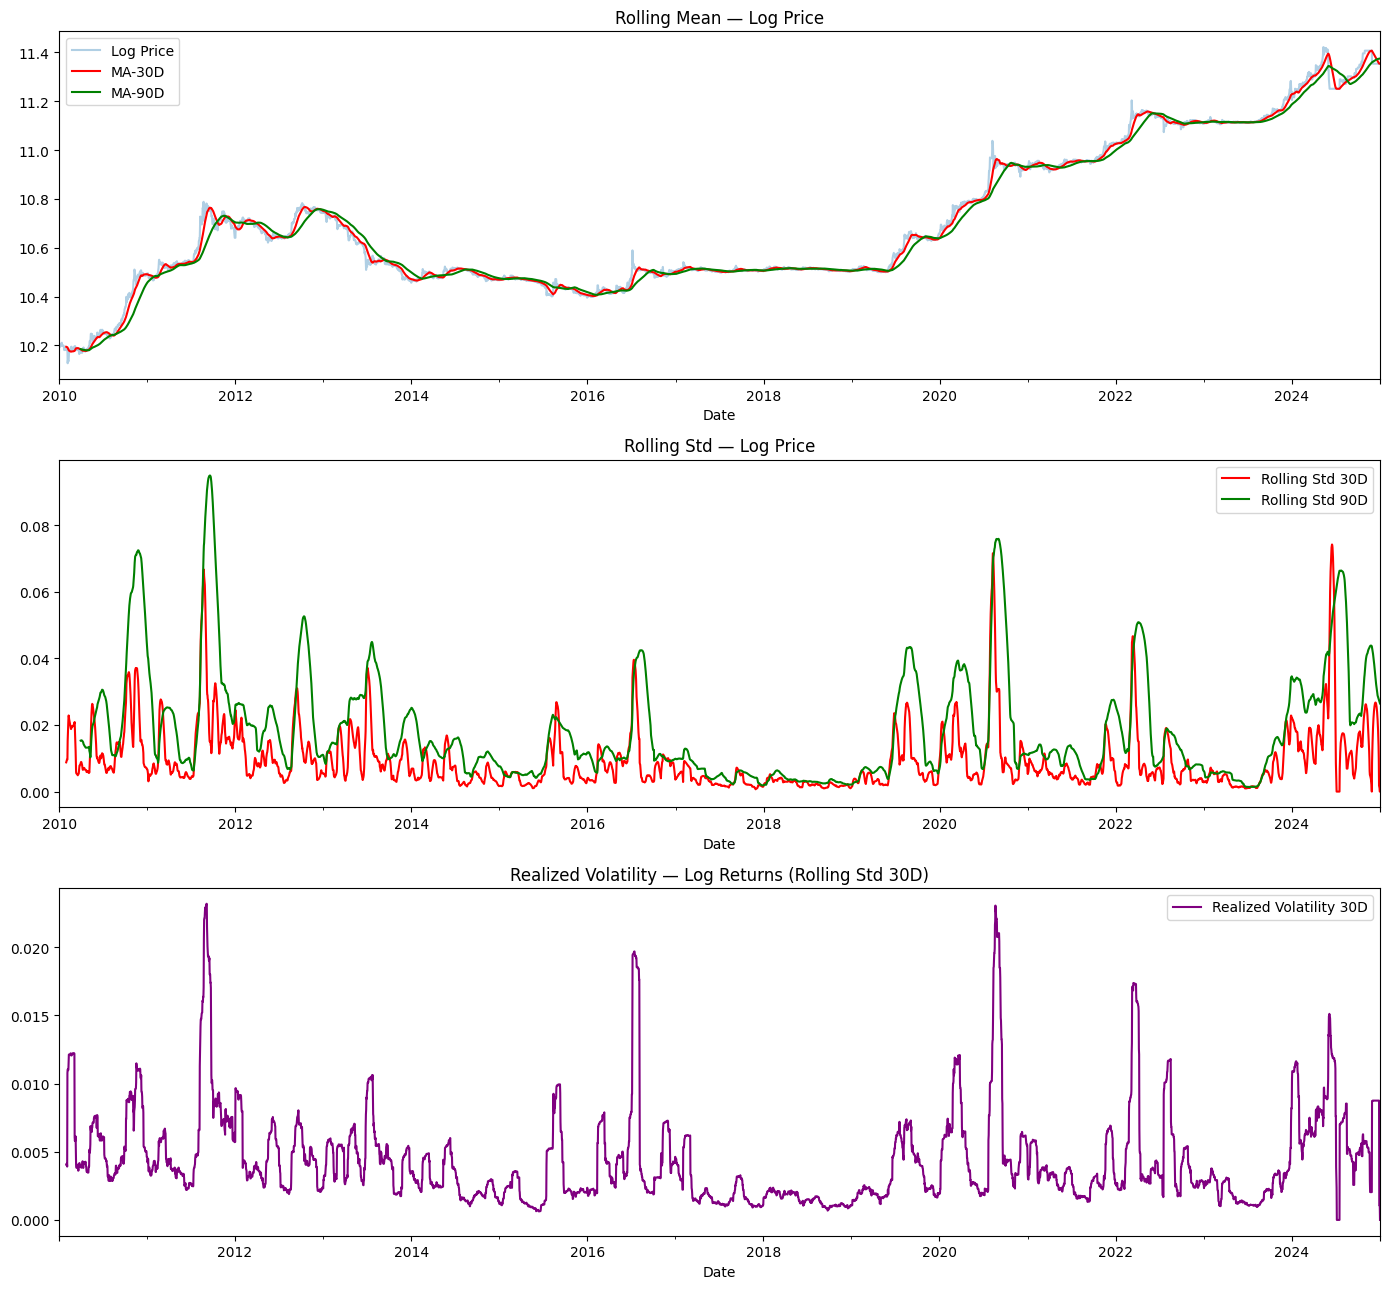

In [8]:
# Phase 2b: Rolling Statistics & Realized Volatility
log_ret = df_log['Sell'].diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Rolling mean trên log price
df_log['Sell'].plot(ax=axes[0], alpha=0.35, label='Log Price')
df_log['Sell'].rolling(30).mean().plot(ax=axes[0], label='MA-30D', color='red')
df_log['Sell'].rolling(90).mean().plot(ax=axes[0], label='MA-90D', color='green')
axes[0].set_title('Rolling Mean — Log Price')
axes[0].legend()

# Rolling std (mức độ biến động của log price)
df_log['Sell'].rolling(30).std().plot(ax=axes[1], label='Rolling Std 30D', color='red')
df_log['Sell'].rolling(90).std().plot(ax=axes[1], label='Rolling Std 90D', color='green')
axes[1].set_title('Rolling Std — Log Price')
axes[1].legend()

# Realized volatility (rolling std of log returns)
log_ret.rolling(30).std().plot(ax=axes[2], label='Realized Volatility 30D', color='purple')
axes[2].set_title('Realized Volatility — Log Returns (Rolling Std 30D)')
axes[2].legend()

plt.tight_layout()
plt.show()


**Nhận xét Phase 2:**
- ADF reject H0 → Log Price NON-stationary; Log Returns STATIONARY → **d = 1** là đủ.
- ACF/PACF của Log Returns cut-off gần ngay lag 1 → ARIMA với p, q nhỏ.
- Realized Volatility không đồng đều qua thời gian → dấu hiệu ARCH effect, cần kiểm tra ở Phase 5.

---
## Phase 4 — Exploratory Modeling: ARIMA

Dùng **giá gốc (VNĐ)** để metrics (MAE/RMSE/MAPE) diễn giải được trực tiếp. Bậc d=1 đã xác nhận từ Phase 2.


## c) Fit mô hình ARIMA (80% Train), Đánh giá và Dự báo tương lai

In [9]:
# Chia train/test 80/20 — dùng giá gốc VNĐ (không dùng df_log)
train_size = int(len(df) * 0.8)
train = df['Sell'][:train_size]
test  = df['Sell'][train_size:]
print(f'Train: {len(train)} ngày  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)}  ngày  ({test.index[0].date()}  → {test.index[-1].date()})')


Train: 4384 ngày  (2010-01-01 → 2022-01-01)
Test : 1096  ngày  (2022-01-02  → 2025-01-01)


In [10]:
# # auto_arima: tìm best (p, d, q) theo AIC; d=1 cố định từ kết quả Phase 2
# stepwise_model = auto_arima(
#     train,
#     start_p=0, start_q=0,
#     max_p=5,   max_q=5,
#     d=1,                        # d=1 đã xác nhận từ ADF test
#     seasonal=False,
#     stepwise=True,
#     trace=True,
#     suppress_warnings=True,
#     information_criterion='aic'
# )
# best_order = stepwise_model.order
# print(f'\n✅ Best order (AIC): ARIMA{best_order}')
# print(stepwise_model.summary())
# stepwise_model.plot_diagnostics(figsize=(15, 8))
# plt.show()


In [11]:
best_order = (5,1,5)

AIC trend='n' (no drift) : 60292.31
AIC trend='t' (drift)    : 60289.01
-> Chon trend='t' (AIC thap hon)
   Mean delta_y = 7.9 VND/ngay

                               SARIMAX Results                                
Dep. Variable:                   Sell   No. Observations:                 4384
Model:                 ARIMA(5, 1, 5)   Log Likelihood              -30132.505
Date:                Tue, 23 Jun 2026   AIC                          60289.011
Time:                        21:56:41   BIC                          60365.637
Sample:                    01-01-2010   HQIC                         60316.047
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             7.9191      3.851      2.056      0.040       0.371      1

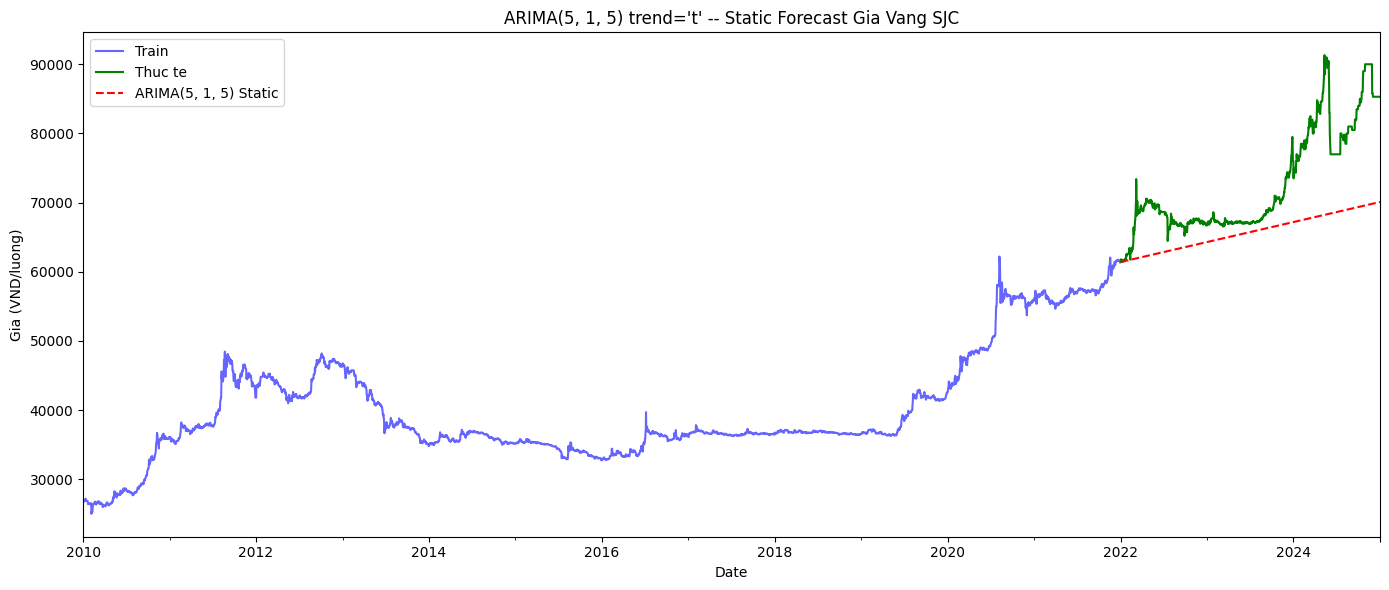

In [12]:
# Kiểm chứng trend: so sanh AIC giua trend='n' (no drift) va trend='t' (drift)
# Statsmodels ARIMA moi: voi d=1, trend='c' KHONG hop le (bi triet tieu boi sai phan)
#   trend='n' -> khong co drift
#   trend='t' -> beta*t trong levels -> sau diff 1 lan -> beta (hang so) = DRIFT
aic_n = ARIMA(train, order=best_order, trend='n').fit().aic
aic_t = ARIMA(train, order=best_order, trend='t').fit().aic
print(f"AIC trend='n' (no drift) : {aic_n:.2f}")
print(f"AIC trend='t' (drift)    : {aic_t:.2f}")
chosen_trend = 't' if aic_t < aic_n else 'n'
print(f"-> Chon trend='{chosen_trend}' (AIC thap hon)")
print(f"   Mean delta_y = {train.diff().dropna().mean():,.1f} VND/ngay")
print()

# Fit ARIMA voi trend da kiem chung
model_arima  = ARIMA(train, order=best_order, trend=chosen_trend)
fitted_arima = model_arima.fit()
print(fitted_arima.summary())

# Static forecast
forecast_arima = fitted_arima.forecast(steps=len(test))
forecast_arima.index = test.index

mae_arima_static  = mean_absolute_error(test, forecast_arima)
rmse_arima_static = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima_static = np.mean(np.abs((test - forecast_arima) / test)) * 100

print(f'Danh gia ARIMA{best_order} (trend={chosen_trend!r}) -- Static Forecast:')
print(f'   MAE  : {mae_arima_static:,.2f}')
print(f'   RMSE : {rmse_arima_static:,.2f}')
print(f'   MAPE : {mape_arima_static:.2f}%')

plt.figure(figsize=(14, 6))
train.plot(label='Train', color='blue', alpha=0.6)
test.plot(label='Thuc te', color='green')
forecast_arima.plot(label=f'ARIMA{best_order} Static', color='red', linestyle='--')
plt.title(f'ARIMA{best_order} trend={chosen_trend!r} -- Static Forecast Gia Vang SJC')
plt.xlabel('Date')
plt.ylabel('Gia (VND/luong)')
plt.legend()
plt.tight_layout()
plt.show()


## d) Expanding Window và Sliding Window

### 🔄 Chiến Lược Khối Cấu Trúc Dữ Liệu: Expanding Window vs Sliding Window

`Expanding` và `Sliding` là 2 phương pháp **"nạp kiến thức"** (huấn luyện và cập nhật mô hình) khác nhau khi thực hiện kiểm định kiểm chứng (backtesting) chuỗi thời gian:

* **Expanding Window (Học sinh nhớ dai):**
  * **Cơ chế:** Ngày nào cũng học thêm kiến thức mới, đồng thời ghi nhớ toàn bộ dữ liệu từ ngày đầu tiên cho đến thời điểm hiện tại.
  * **Triết lý:** Tin rằng lịch sử càng dài thì nền tảng mô hình càng vững chắc và đáng tin cậy.
* **Sliding Window (Học sinh cuốn chiếu):**
  * **Cơ chế:** Ngày nào cũng học kiến thức mới, nhưng bộ nhớ chỉ giữ lại một khoảng thời gian cố định (ví dụ: đúng 365 ngày gần nhất), các dữ liệu xa hơn sẽ bị xóa sạch.
  * **Triết lý:** Tin rằng thế giới và thị trường thay đổi liên tục, những câu chuyện của 2–3 năm trước không còn giá trị tham chiếu cho ngày mai nữa.

---

📌 **Mục đích thử nghiệm:** Việc chạy song song cả 2 chiến lược này là để xác định xem với bộ dữ liệu cụ thể của bạn (ví dụ: giá vàng), thị trường đang thiên về xu hướng **"nhớ dai"** (bị ảnh hưởng bởi lịch sử dài hạn) hay **"mau quên"** (chỉ phản ứng với các biến động ngắn hạn).


Expanding Window đang chạy...
   Bước 0/1096
   Bước 200/1096
   Bước 400/1096
   Bước 600/1096
   Bước 800/1096
   Bước 1000/1096
   Xong ✅

Sliding Window đang chạy...
   Bước 0/1096
   Bước 200/1096
   Bước 400/1096
   Bước 600/1096
   Bước 800/1096
   Bước 1000/1096
   Xong ✅


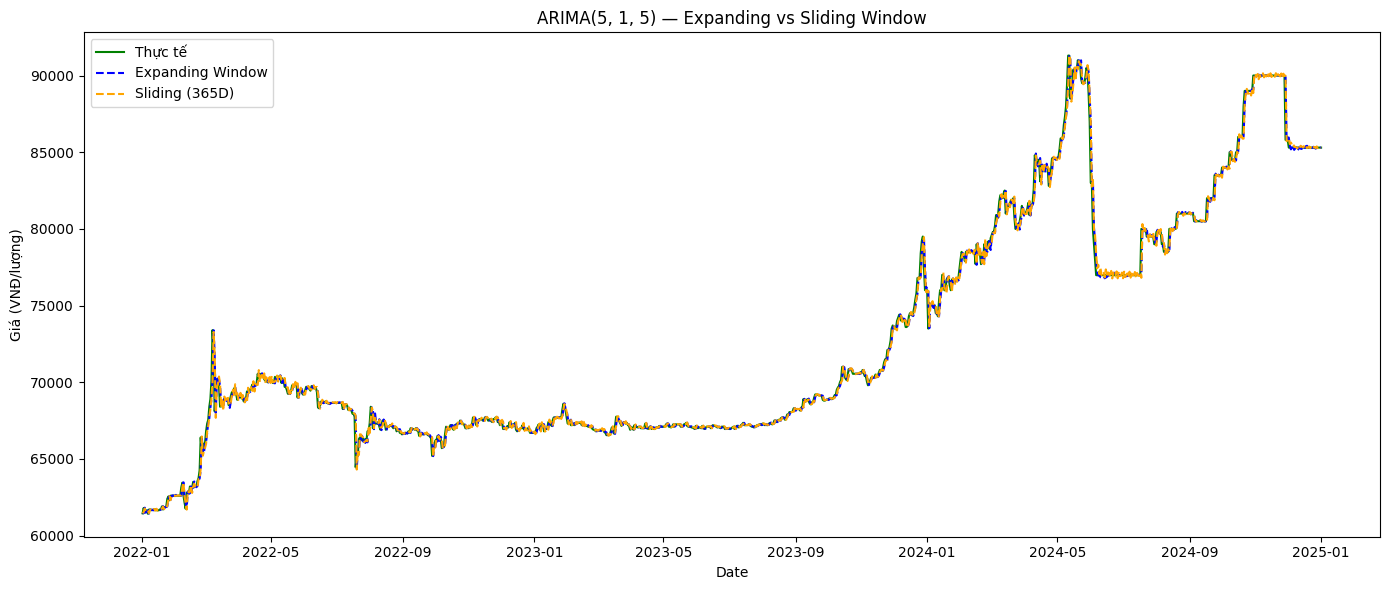


Phương pháp                     MAE       RMSE     MAPE
ARIMA Static                  6,918      8,901    8.90%
Expanding Window                222        468    0.30%
Sliding (365D)                  242        481    0.33%


In [ ]:
close = df['Sell'].values      # dùng giá gốc (df['Sell']), không phải df_log
train_size = int(len(close) * 0.8)

# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 1: EXPANDING WINDOW
# Fit 1 lần trên train; mỗi bước append observation mới với
# refit=False → cập nhật state, KHÔNG ước lượng lại tham số
# Nhanh hơn ~1000x so với refit toàn bộ từ đầu mỗi bước
# ══════════════════════════════════════════════════════════════
print('Expanding Window đang chạy...')
expanding_preds = []

fitted_exp = ARIMA(close[:train_size], order=best_order, trend=chosen_trend).fit()
for i in range(train_size, len(close)):
    pred = fitted_exp.forecast(steps=1)[0]
    expanding_preds.append(pred)
    fitted_exp = fitted_exp.append([close[i]], refit=False)
    if (i - train_size) % 200 == 0:
        print(f'   Bước {i - train_size}/{len(close) - train_size}')
print('   Xong ✅')



Sliding Window đang chạy...
   Bước 0/1096
   Bước 200/1096
   Bước 400/1096
   Bước 600/1096
   Bước 800/1096
   Bước 1000/1096
   Xong ✅


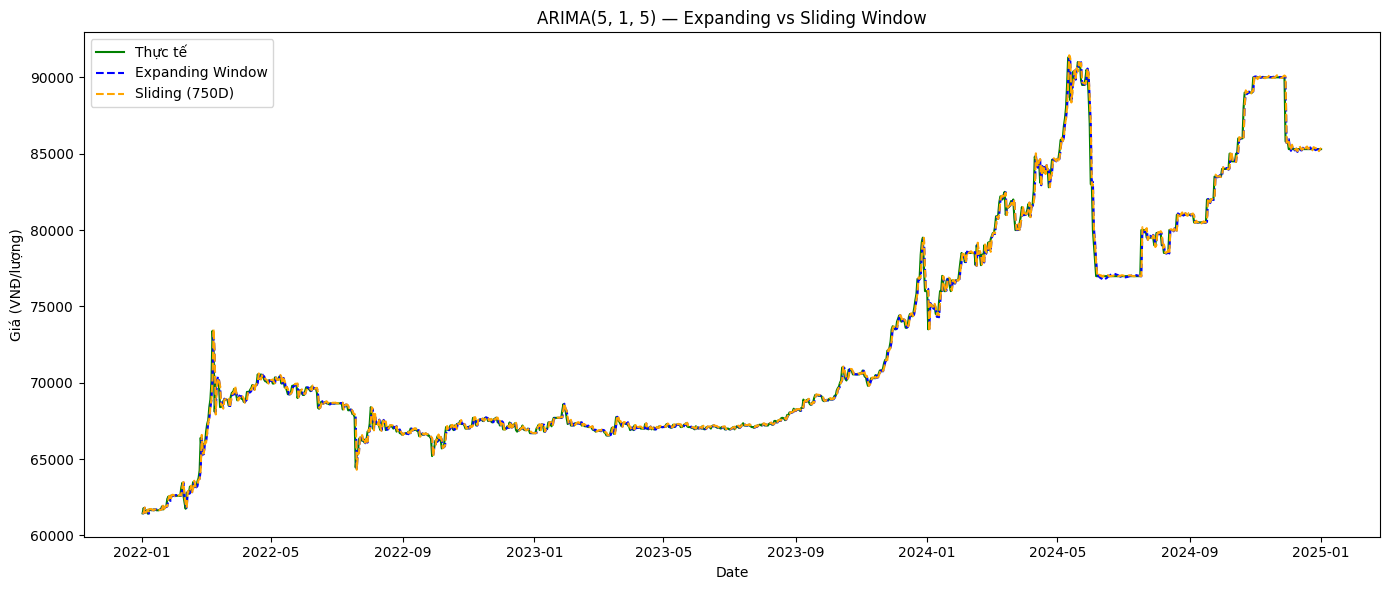


Phương pháp                     MAE       RMSE     MAPE
ARIMA Static                  6,918      8,901    8.90%
Expanding Window                222        468    0.30%
Sliding (750D)                  225        467    0.30%


In [20]:

# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 2: SLIDING WINDOW
# Fit 1 lần trên cửa sổ đầu tiên; mỗi bước apply sang cửa
# sổ mới với refit=False → giữ nguyên tham số, cập nhật state
# ══════════════════════════════════════════════════════════════
print('\nSliding Window đang chạy...')
sliding_preds = []
window_size   = 365 * 2  # 1 năm calendar

fitted_sld = ARIMA(
    close[train_size - window_size:train_size],
    order=best_order, trend=chosen_trend
).fit()

for i in range(train_size, len(close)):
    pred = fitted_sld.forecast(steps=1)[0]
    sliding_preds.append(pred)
    new_window = close[max(0, i - window_size + 1):i + 1]
    fitted_sld = fitted_sld.apply(new_window, refit=False)
    if (i - train_size) % 200 == 0:
        print(f'   Bước {i - train_size}/{len(close) - train_size}')
print('   Xong ✅')

# ── Metrics ──────────────────────────────────────────────────
actual = close[train_size:]
dates  = df.index[train_size:]

def get_metrics(act, pred):
    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    mape = np.mean(np.abs((act - pred) / act)) * 100
    return mae, rmse, mape

mae_exp, rmse_exp, mape_exp = get_metrics(actual, expanding_preds)
mae_sld, rmse_sld, mape_sld = get_metrics(actual, sliding_preds)

# ── Biểu đồ ──────────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(dates, actual,          label='Thực tế',          color='green')
plt.plot(dates, expanding_preds, label='Expanding Window', color='blue',   linestyle='--')
plt.plot(dates, sliding_preds,   label='Sliding (750D)',   color='orange', linestyle='--')
plt.title(f'ARIMA{best_order} — Expanding vs Sliding Window')
plt.xlabel('Date')
plt.ylabel('Giá (VNĐ/lượng)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Bảng so sánh — TẤT CẢ tính từ code, không hardcode ──────
print('\n' + '='*62)
print(f'{"Phương pháp":<24} {"MAE":>10} {"RMSE":>10} {"MAPE":>8}')
print('='*62)
print(f'{"ARIMA Static":<24} {mae_arima_static:>10,.0f} {rmse_arima_static:>10,.0f} {mape_arima_static:>7.2f}%')
print(f'{"Expanding Window":<24} {mae_exp:>10,.0f} {rmse_exp:>10,.0f} {mape_exp:>7.2f}%')
print(f'{"Sliding (750D)":<24} {mae_sld:>10,.0f} {rmse_sld:>10,.0f} {mape_sld:>7.2f}%')
print('='*62)


**Nhận xét — Expanding vs Sliding Window:**
- **Expanding Window**: tận dụng toàn bộ lịch sử, phù hợp khi cấu trúc thị trường ổn định.
- **Sliding (750D)**: chỉ dùng 1 năm gần nhất, thích nghi tốt hơn khi có thay đổi cấu trúc.

---
## Phase 5 — Residual Diagnostics
Kiểm tra phần dư ARIMA: autocorrelation (Ljung-Box), heteroskedasticity (ARCH test), phân phối.




###  Trực Quan Hóa Phần Dư (Visual Diagnostics)
Mục đích: Vẽ ra **5 biểu đồ** để đánh giá phần dư bằng mắt thường.

* **Residuals theo thời gian (Line plot):**
  * Kiểm tra sai số có dao động đều quanh mức 0 hay không.
  * Nếu biên độ dao động lúc to lúc nhỏ, dữ liệu có thể bị phương sai thay đổi (*heteroskedasticity*).
* **Histogram:**
  * Xem xét phân phối của phần dư có hình chuông (chuẩn) không.
* **ACF & PACF:**
  * Kiểm tra tự tương quan.
  * Nếu các cột (lags) vượt ra khỏi vùng xanh (vùng tin cậy) $\rightarrow$ Các sai số vẫn có mối liên hệ trong quá khứ (mô hình chưa tốt).
* **Q-Q Plot:**
  * So sánh phân phối của phần dư với phân phối chuẩn.
  * Các điểm nằm sát đường chéo màu đỏ $\rightarrow$ Phần dư tuân theo phân phối chuẩn.



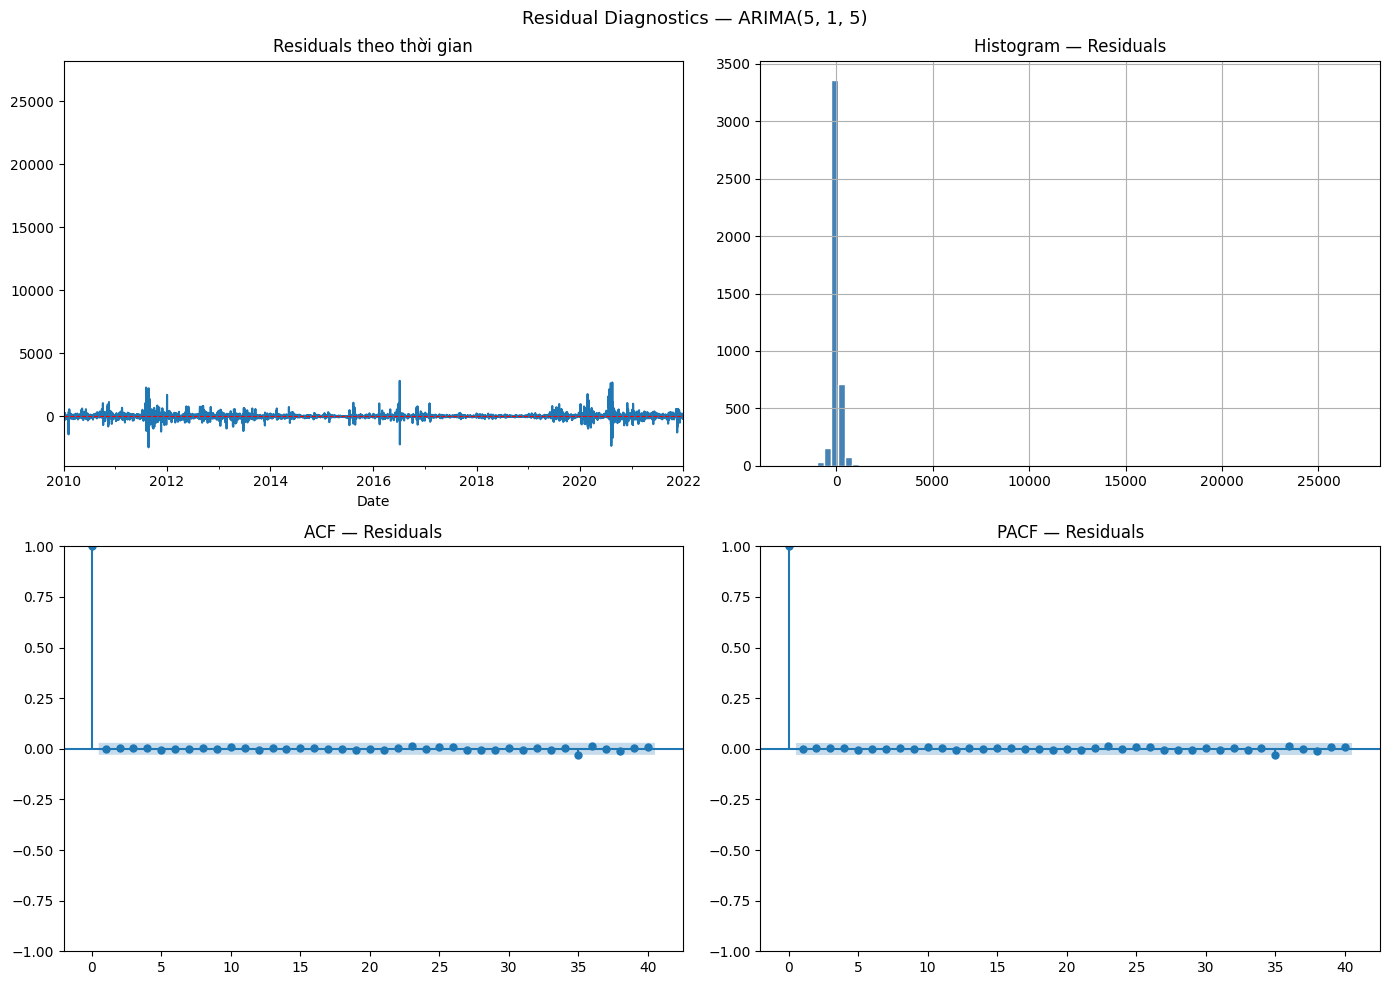

=== Ljung-Box Test — ARIMA(5, 1, 5) ===
     lb_stat  lb_pvalue
10  0.998711   0.999829
20  1.390722   1.000000
30  3.306197   1.000000

→ Phần dư là white noise ✅



In [15]:
# Phase 5a: Kiểm tra phần dư ARIMA — biểu đồ tổng quan
residuals = pd.Series(fitted_arima.resid.values, index=train.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

residuals.plot(ax=axes[0, 0], title='Residuals theo thời gian')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)

residuals.hist(bins=80, ax=axes[0, 1], color='steelblue', edgecolor='white')
axes[0, 1].set_title('Histogram — Residuals')

plot_acf(residuals,  ax=axes[1, 0], lags=40, title='ACF — Residuals')
plot_pacf(residuals, ax=axes[1, 1], lags=40, title='PACF — Residuals')

plt.suptitle(f'Residual Diagnostics — ARIMA{best_order}', fontsize=13)
plt.tight_layout()
plt.show()




lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(f'=== Ljung-Box Test — ARIMA{best_order} ===')
print(lb.to_string())
print(f'\n→ {"Phần dư là white noise ✅" if (lb["lb_pvalue"] > 0.05).all() else "Còn autocorrelation trong phần dư ⚠️ — xem lại order"}')

print()


## SARIMA

### ⚠️ Hạn Chế Của Mô Hình SARIMA Đối Với Dữ Liệu Theo Ngày

Vấn đề cốt lõi nằm ở cách mô hình **SARIMA** định nghĩa thành phần **"Mùa vụ" (Seasonality)** thông qua tham số $s$ (hoặc $m$):

* **Cơ chế hoạt động:** Để nhận diện tính mùa vụ, SARIMA không sử dụng lịch cấu trúc (calendar) như con người, mà dựa hoàn toàn vào **Độ trễ (Lags)**.
* **Hệ quả với dữ liệu ngày:** Để bắt được tính mùa vụ theo năm, mô hình buộc phải tính toán các mối tương quan trễ lên tới **365 bước** ($s = 365$).
* **Thách thức:** Dữ liệu theo ngày thường chứa rất nhiều **"rác" ngắn hạn (nhiễu/noise)**. Việc cấu hình số bước trễ quá lớn vừa gây bùng nổ chi phí tính toán, vừa khiến mô hình dễ bị nhiễu và giảm độ chính xác.
